In [1]:
import pandas as pd

df = pd.read_excel("mls_attendance_clean.xlsx")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'mls_attendance_clean.xlsx'

In [2]:
import pandas as pd

df = pd.read_excel("mls_attendance_clean.xlsx")

df.head()

,Date,Season,HomeTeam,AwayTeam,Attendance
0,2022-02-26,2022,LAFC,Colorado Rapids,22010
1,2022-02-26,2022,Philadelphia Union,Minnesota Utd,17487
2,2022-02-26,2022,SJ Earthquakes,NY Red Bulls,16146
3,2022-02-26,2022,Columbus Crew,Vancouver W'caps,18939
4,2022-02-26,2022,FC Dallas,Toronto FC,12233


In [3]:
import os
os.listdir()

['.ipynb_checkpoints',
 'anaconda_projects',
 'mls_attendance_clean.xlsx',
 'mls_messi_attendance_analysis']

In [4]:
import pandas as pd

df = pd.read_excel("mls_attendance_clean.xlsx")
df.head()

,Date,Season,HomeTeam,AwayTeam,Attendance
0,2022-02-26,2022,LAFC,Colorado Rapids,22010
1,2022-02-26,2022,Philadelphia Union,Minnesota Utd,17487
2,2022-02-26,2022,SJ Earthquakes,NY Red Bulls,16146
3,2022-02-26,2022,Columbus Crew,Vancouver W'caps,18939
4,2022-02-26,2022,FC Dallas,Toronto FC,12233


In [5]:
df["Date"] = pd.to_datetime(df["Date"])

df["Miami_Home"] = (df["HomeTeam"] == "Inter Miami").astype(int)
df["Post_Messi"] = (df["Date"] >= "2023-07-15").astype(int)
df["Interaction"] = df["Miami_Home"] * df["Post_Messi"]

df.head()

,Date,Season,HomeTeam,AwayTeam,Attendance,Miami_Home,Post_Messi,Interaction
0,2022-02-26,2022,LAFC,Colorado Rapids,22010,0,0,0
1,2022-02-26,2022,Philadelphia Union,Minnesota Utd,17487,0,0,0
2,2022-02-26,2022,SJ Earthquakes,NY Red Bulls,16146,0,0,0
3,2022-02-26,2022,Columbus Crew,Vancouver W'caps,18939,0,0,0
4,2022-02-26,2022,FC Dallas,Toronto FC,12233,0,0,0


In [6]:
df[["Miami_Home", "Post_Messi", "Interaction"]].sum()

Miami_Home      33
Post_Messi     199
Interaction      6
dtype: int64

In [7]:
df[df["HomeTeam"] == "Inter Miami"].head(10)

,Date,Season,HomeTeam,AwayTeam,Attendance,Miami_Home,Post_Messi,Interaction
7,2022-02-26,2022,Inter Miami,Chicago Fire,15973,1,0,0
31,2022-03-12,2022,Inter Miami,LAFC,11465,1,0,0
72,2022-04-02,2022,Inter Miami,Houston Dynamo,13083,1,0,0
74,2022-04-09,2022,Inter Miami,NE Revolution,11472,1,0,0
103,2022-04-24,2022,Inter Miami,Atlanta Utd,13433,1,0,0
154,2022-05-14,2022,Inter Miami,D.C. United,13317,1,0,0
173,2022-05-22,2022,Inter Miami,NY Red Bulls,11007,1,0,0
190,2022-05-28,2022,Inter Miami,Portland Timbers,11161,1,0,0
221,2022-06-25,2022,Inter Miami,Minnesota Utd,12147,1,0,0
270,2022-07-13,2022,Inter Miami,Philadelphia Union,10027,1,0,0


In [8]:
df.to_csv("mls_attendance_processed.csv", index=False)

In [9]:
df.groupby("Post_Messi")["Attendance"].mean()
df[df["Miami_Home"] == 1].groupby("Post_Messi")["Attendance"].mean()

Post_Messi
0    14189.592593
1    19926.666667
Name: Attendance, dtype: float64

In [10]:
import statsmodels.formula.api as smf

model = smf.ols(
    "Attendance ~ Miami_Home + Post_Messi + Interaction",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Attendance   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     8.339
Date:                Sun, 15 Mar 2026   Prob (F-statistic):           1.77e-05
Time:                        12:12:40   Log-Likelihood:                -10500.
No. Observations:                1005   AIC:                         2.101e+04
Df Residuals:                    1001   BIC:                         2.103e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    2.161e+04    299.418     72.186      

<Axes: xlabel='Post_Messi'>

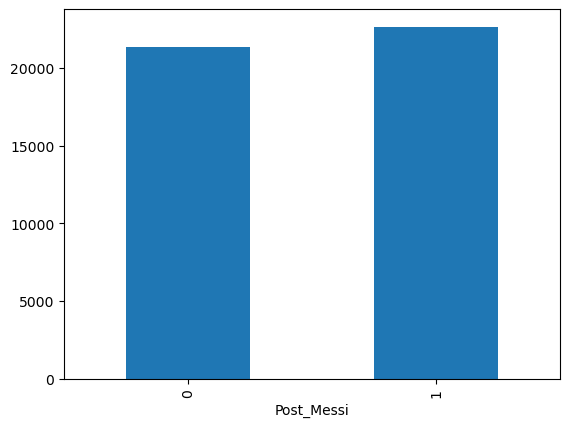

In [11]:
df.groupby("Post_Messi")["Attendance"].mean().plot(kind="bar")

<Axes: xlabel='Post_Messi'>

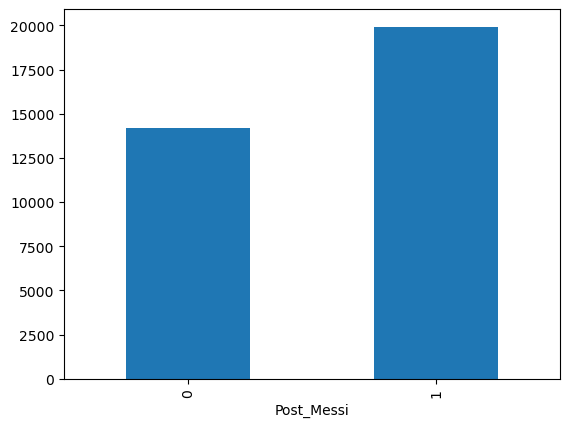

In [12]:
df[df["Miami_Home"] == 1].groupby("Post_Messi")["Attendance"].mean().plot(kind="bar")

In [13]:
Attendance ~ Miami_Home + Post_Messi + Interaction + Capacity

SyntaxError: invalid syntax (3007305220.py, line 1)

In [14]:
import pandas as pd

capacity_data = {
    "HomeTeam": [
        "Atlanta Utd","Austin FC","Charlotte FC","Chicago Fire","Colorado Rapids",
        "Columbus Crew","D.C. United","FC Cincinnati","FC Dallas","Houston Dynamo",
        "Inter Miami","LA Galaxy","LAFC","Minnesota Utd","CF Montréal",
        "Nashville SC","NE Revolution","NY Red Bulls","NYCFC","Orlando City",
        "Philadelphia Union","Portland Timbers","Real Salt Lake","San Jose Earthquakes",
        "Seattle Sounders","Sporting KC","Toronto FC","Vancouver Whitecaps"
    ],
    "Stadium_Capacity": [
        42000,20738,38102,20000,18061,
        20371,20000,26000,20500,22039,
        18000,27000,22000,19400,19619,
        30000,20628,25000,25000,25500,
        18500,25218,20213,18000,
        37000,18467,28000,22000
    ]
}

capacity_df = pd.DataFrame(capacity_data)

capacity_df.head()

,HomeTeam,Stadium_Capacity
0,Atlanta Utd,42000
1,Austin FC,20738
2,Charlotte FC,38102
3,Chicago Fire,20000
4,Colorado Rapids,18061


In [15]:
df = df.merge(capacity_df, on="HomeTeam", how="left")

df.head()

,Date,Season,HomeTeam,AwayTeam,Attendance,Miami_Home,Post_Messi,Interaction,Stadium_Capacity
0,2022-02-26,2022,LAFC,Colorado Rapids,22010,0,0,0,22000.0
1,2022-02-26,2022,Philadelphia Union,Minnesota Utd,17487,0,0,0,18500.0
2,2022-02-26,2022,SJ Earthquakes,NY Red Bulls,16146,0,0,0,NaN
3,2022-02-26,2022,Columbus Crew,Vancouver W'caps,18939,0,0,0,20371.0
4,2022-02-26,2022,FC Dallas,Toronto FC,12233,0,0,0,20500.0


In [16]:
df["Attendance_Rate"] = df["Attendance"] / df["Stadium_Capacity"]

df[["Attendance","Stadium_Capacity","Attendance_Rate"]].head()

,Attendance,Stadium_Capacity,Attendance_Rate
0,22010,22000.0,1.000455
1,17487,18500.0,0.945243
2,16146,NaN,NaN
3,18939,20371.0,0.929704
4,12233,20500.0,0.596732


In [17]:
df.groupby("Post_Messi")["Attendance_Rate"].mean()

Post_Messi
0    0.895856
1    0.951514
Name: Attendance_Rate, dtype: float64

In [18]:
df[df["HomeTeam"] == "Inter Miami"].groupby("Post_Messi")["Attendance_Rate"].mean()

Post_Messi
0    0.788311
1    1.107037
Name: Attendance_Rate, dtype: float64

In [19]:
import statsmodels.formula.api as smf

rate_model = smf.ols(
    "Attendance_Rate ~ Miami_Home + Post_Messi + Interaction",
    data=df
).fit()

print(rate_model.summary())

                            OLS Regression Results                            
Dep. Variable:        Attendance_Rate   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     6.829
Date:                Sun, 15 Mar 2026   Prob (F-statistic):           0.000150
Time:                        14:15:12   Log-Likelihood:                 127.09
No. Observations:                 848   AIC:                            -246.2
Df Residuals:                     844   BIC:                            -227.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.9003      0.008    110.190      

In [20]:
df["Attendance_Rate"] = df["Attendance"] / df["Stadium_Capacity"]

In [1]:
Attendance_Rate ~ Miami_Home + Post_Messi + Interaction

SyntaxError: invalid syntax (2565395740.py, line 1)

In [2]:
import statsmodels.formula.api as smf

model = smf.ols(
    "Attendance_Rate ~ Miami_Home + Post_Messi + Interaction",
    data=df
).fit()

print(model.summary())

NameError: name 'df' is not defined

In [3]:
import pandas as pd

df = pd.read_excel("mls_attendance_clean.xlsx")

df.head()

,Date,Season,HomeTeam,AwayTeam,Attendance
0,2022-02-26,2022,LAFC,Colorado Rapids,22010
1,2022-02-26,2022,Philadelphia Union,Minnesota Utd,17487
2,2022-02-26,2022,SJ Earthquakes,NY Red Bulls,16146
3,2022-02-26,2022,Columbus Crew,Vancouver W'caps,18939
4,2022-02-26,2022,FC Dallas,Toronto FC,12233


In [4]:
import statsmodels.formula.api as smf

model = smf.ols(
    "Attendance_Rate ~ Miami_Home + Post_Messi + Interaction",
    data=df
).fit()

print(model.summary())

PatsyError: Error evaluating factor: NameError: name 'Miami_Home' is not defined
    Attendance_Rate ~ Miami_Home + Post_Messi + Interaction
                      ^^^^^^^^^^

In [5]:
df.columns

Index(['Date', 'Season', 'HomeTeam', 'AwayTeam', 'Attendance'], dtype='object')

In [6]:
df["Miami_Home"] = (df["HomeTeam"] == "Inter Miami").astype(int)

In [7]:
df["Date"] = pd.to_datetime(df["Date"])

df["Post_Messi"] = (df["Date"] >= "2023-07-15").astype(int)

In [8]:
df["Interaction"] = df["Miami_Home"] * df["Post_Messi"]

In [9]:
import statsmodels.formula.api as smf

model = smf.ols(
    "Attendance_Rate ~ Miami_Home + Post_Messi + Interaction",
    data=df
).fit()

print(model.summary())

PatsyError: Error evaluating factor: NameError: name 'Attendance_Rate' is not defined
    Attendance_Rate ~ Miami_Home + Post_Messi + Interaction
    ^^^^^^^^^^^^^^^

In [10]:
print(df.columns.tolist())

['Date', 'Season', 'HomeTeam', 'AwayTeam', 'Attendance', 'Miami_Home', 'Post_Messi', 'Interaction']


In [11]:
df["Attendance"] = pd.to_numeric(df["Attendance"], errors="coerce")
df["Capacity"] = pd.to_numeric(df["Capacity"], errors="coerce")

df["Attendance_Rate"] = df["Attendance"] / df["Capacity"]

KeyError: 'Capacity'

In [12]:
print(df.columns.tolist())

['Date', 'Season', 'HomeTeam', 'AwayTeam', 'Attendance', 'Miami_Home', 'Post_Messi', 'Interaction']


In [13]:
import pandas as pd
import statsmodels.formula.api as smf

df["Attendance"] = pd.to_numeric(df["Attendance"], errors="coerce")
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["Miami_Home"] = (df["HomeTeam"] == "Inter Miami").astype(int)
df["Post_Messi"] = (df["Date"] >= "2023-07-15").astype(int)
df["Interaction"] = df["Miami_Home"] * df["Post_Messi"]

reg_df = df[["Attendance", "Miami_Home", "Post_Messi", "Interaction"]].dropna()

model = smf.ols(
    "Attendance ~ Miami_Home + Post_Messi + Interaction",
    data=reg_df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Attendance   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     8.339
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           1.77e-05
Time:                        00:34:18   Log-Likelihood:                -10500.
No. Observations:                1005   AIC:                         2.101e+04
Df Residuals:                    1001   BIC:                         2.103e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    2.161e+04    299.418     72.186      

In [16]:
df["Miami_Away"] = (df["AwayTeam"] == "Inter Miami").astype(int)

df["Away_Interaction"] = df["Miami_Away"] * df["Post_Messi"]

In [15]:
away_model = smf.ols(
    "Attendance ~ Miami_Away + Post_Messi + Away_Interaction",
    data=df
).fit()

print(away_model.summary())

                            OLS Regression Results                            
Dep. Variable:             Attendance   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.041
Method:                 Least Squares   F-statistic:                     15.20
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           1.11e-09
Time:                        00:44:24   Log-Likelihood:                -10490.
No. Observations:                1005   AIC:                         2.099e+04
Df Residuals:                    1001   BIC:                         2.101e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         2.133e+04    296.648  

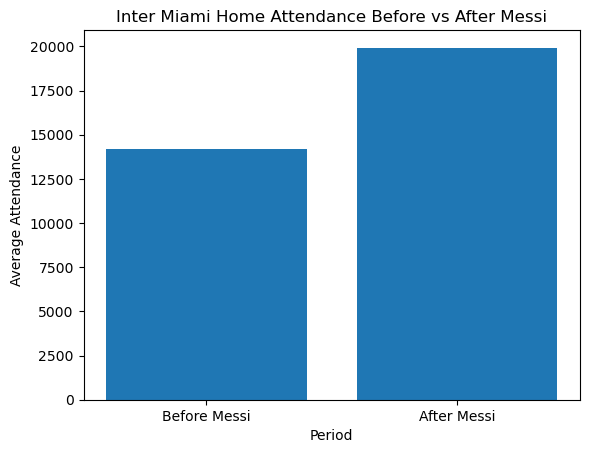

In [17]:
import matplotlib.pyplot as plt

home_games = df[df["HomeTeam"] == "Inter Miami"]

before_home = home_games[home_games["Post_Messi"] == 0]["Attendance"].mean()
after_home = home_games[home_games["Post_Messi"] == 1]["Attendance"].mean()

plt.figure()
plt.bar(["Before Messi", "After Messi"], [before_home, after_home])
plt.title("Inter Miami Home Attendance Before vs After Messi")
plt.ylabel("Average Attendance")
plt.xlabel("Period")
plt.show()

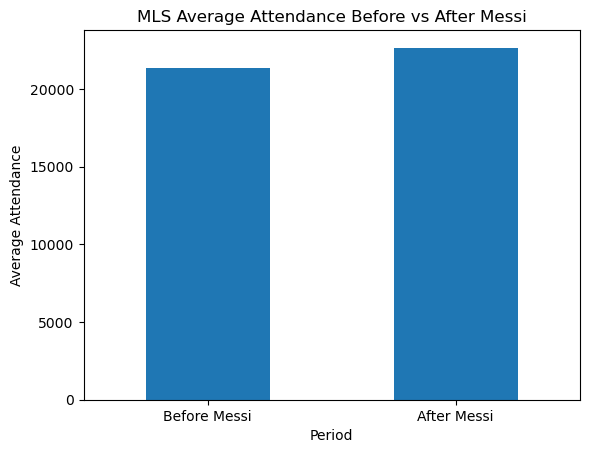

In [18]:
league_attendance = df.groupby("Post_Messi")["Attendance"].mean()

plt.figure()
league_attendance.plot(kind="bar")
plt.title("MLS Average Attendance Before vs After Messi")
plt.ylabel("Average Attendance")
plt.xlabel("Period")
plt.xticks([0,1], ["Before Messi","After Messi"], rotation=0)
plt.show()

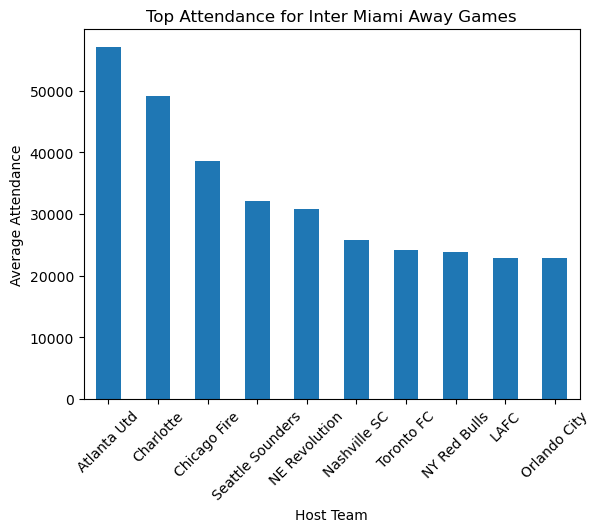

In [19]:
away_games = df[df["AwayTeam"] == "Inter Miami"]

team_avg = away_games.groupby("HomeTeam")["Attendance"].mean().sort_values(ascending=False).head(10)

plt.figure()
team_avg.plot(kind="bar")
plt.title("Top Attendance for Inter Miami Away Games")
plt.ylabel("Average Attendance")
plt.xlabel("Host Team")
plt.xticks(rotation=45)
plt.show()

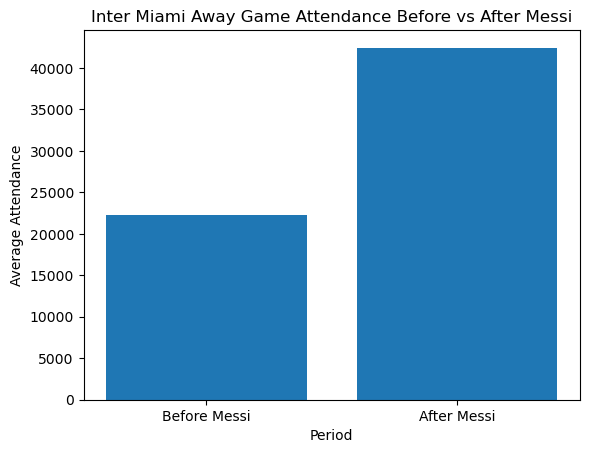

In [20]:
away_games = df[df["AwayTeam"] == "Inter Miami"]

before_away = away_games[away_games["Post_Messi"] == 0]["Attendance"].mean()
after_away = away_games[away_games["Post_Messi"] == 1]["Attendance"].mean()

plt.figure()
plt.bar(["Before Messi", "After Messi"], [before_away, after_away])
plt.title("Inter Miami Away Game Attendance Before vs After Messi")
plt.ylabel("Average Attendance")
plt.xlabel("Period")
plt.show()

In [21]:
df.to_csv("mls_messi_analysis_tableau.csv", index=False)

In [22]:
Messi_Game

NameError: name 'Messi_Game' is not defined

In [23]:
df["Messi_Game"] = df["Home"].apply(lambda x: "Messi" if x == "Inter Miami" else "Non-Messi")

KeyError: 'Home'

In [24]:
df["Messi_Game"] = df["HomeTeam"].apply(lambda x: "Messi" if x == "Inter Miami" else "Non-Messi")

In [25]:
df[["HomeTeam", "AwayTeam", "Attendance", "Messi_Game"]].head()

,HomeTeam,AwayTeam,Attendance,Messi_Game
0,LAFC,Colorado Rapids,22010,Non-Messi
1,Philadelphia Union,Minnesota Utd,17487,Non-Messi
2,SJ Earthquakes,NY Red Bulls,16146,Non-Messi
3,Columbus Crew,Vancouver W'caps,18939,Non-Messi
4,FC Dallas,Toronto FC,12233,Non-Messi


In [26]:
df.groupby("Messi_Game")["Attendance"].mean()

Messi_Game
Messi        15232.696970
Non-Messi    21836.147119
Name: Attendance, dtype: float64